<a href="https://colab.research.google.com/github/irakafc/Portfolio/blob/Projects/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `satisfaccion` representa una escala ordinal de 1 a 5, aunque puede analizarse como numérica para fines exploratorios y de correlación.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:

# Estadísticas descriptivas de variables numéricas

columnas_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

print(df[columnas_numericas].describe())

               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  ingreso_anual  
count               15000.000000  15000.000000   15000.000000  
mean                   20.149301      3.603693      36.594180  
std                    10.880724      0.685300      34.484888  
min                     0.000000      1.000000       0.000000  
25%                    12.310000      3.100000       0.000000  
50%                  

### Diagnóstico inicial de variables numéricas

- `edad` — La edad promedio es de aproximadamente 38 años, con un rango entre 18 y 75 años. No se observan valores imposibles o inconsistentes.

- `nivel_ingreso` — Los ingresos presentan una dispersión considerable (std ≈ 9,833), lo que sugiere diferencias importantes entre clientes de distintos niveles económicos.

- `visitas_mes` — La mayoría de los clientes realiza entre 8 y 12 visitas mensuales, aunque algunos alcanzan hasta 25 visitas, lo que podría indicar usuarios altamente activos.

- `compras_mes` — La mediana es de 1 compra mensual y existen clientes con hasta 8 compras, mostrando una distribución sesgada hacia valores bajos.

- `gasto_publicidad_dirigida` — Existen clientes con gasto publicitario muy alto en comparación con la media, lo que podría indicar posibles outliers o segmentaciones premium.

- `satisfaccion` — La satisfacción promedio es de 3.6 sobre 5, lo que refleja una percepción generalmente positiva de los clientes.

- `ingreso_anual` — La variable presenta alta dispersión y valores máximos considerablemente elevados respecto a la mediana, lo que sugiere presencia de outliers o clientes altamente rentables.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ["miembro_premium", "abandono"]

for col in columnas_binarias:
    print(col)
    print(df[col].value_counts())
    print()

miembro_premium
0    12911
1     2089
Name: miembro_premium, dtype: int64

abandono
0    12739
1     2261
Name: abandono, dtype: int64



Diagnóstico inicial de variables binarias


- `miembro_premium` — La mayoría de los clientes no pertenece al programa premium, ya que los valores 0 representan una proporción considerablemente mayor que los valores 1.

- `abandono` — La mayor parte de los clientes permanece activa en la plataforma, mientras que una menor proporción ha abandonado el servicio.

#### Explorar variables categóricas

In [ ]:

# Verificar el número de valores únicos por variable categórica


columnas_categoricas = ["id_cliente", "tipo_dispositivo", "region"]

for col in columnas_categoricas:
    print(col)
    print(df[col].nunique())
    print()

id_cliente
15000

tipo_dispositivo
3

region
4



In [ ]:

# Explorar variables categóricas y cómo se distribuyen

columnas_categoricas = ["tipo_dispositivo", "region"]

for col in columnas_categoricas:
    print(col)
    print(df[col].value_counts())
    print()


tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64



Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — La mayoría de los clientes utiliza dispositivos móviles, mientras que tablet presenta la menor cantidad de registros. Esto indica una fuerte preferencia por el acceso móvil.

- `region` — La distribución regional es relativamente equilibrada, aunque la región norte concentra la mayor cantidad de clientes y la región este la menor participación.


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

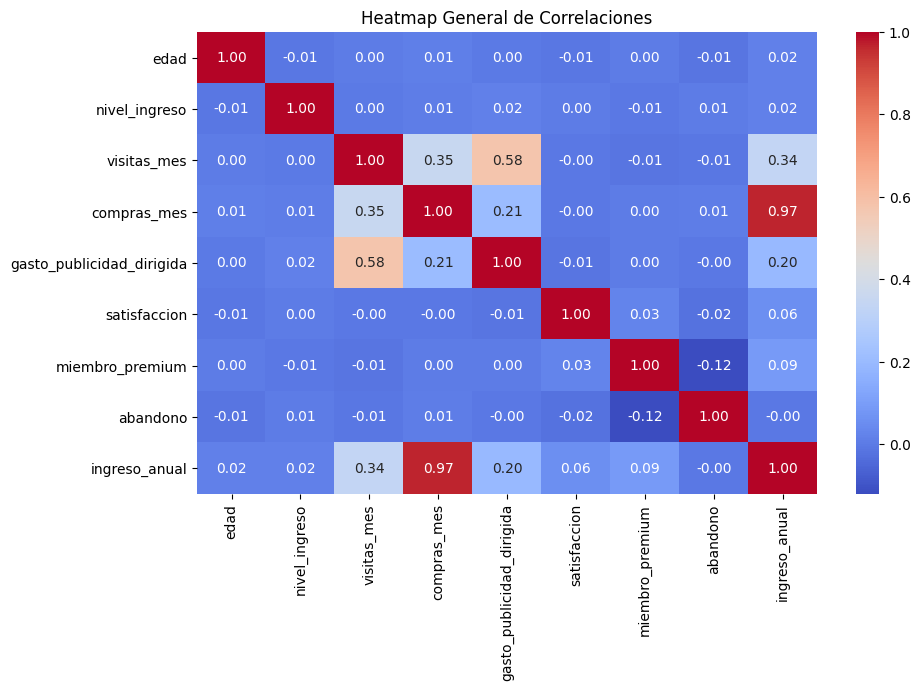

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar columnas numéricas
columnas_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "miembro_premium",
    "abandono",
    "ingreso_anual"
]

# Calcular matriz de correlación
corr_matrix = df[columnas_numericas].corr()

# Crear heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Título
plt.title("Heatmap General de Correlaciones")

plt.show()

# 📊 Interpretación del Heatmap de Correlaciones

---

## Observaciones Generales

La gran mayoría de las correlaciones son **cercanas a 0**, lo que indica que las variables son en su mayoría **independientes entre sí**. Sin embargo, destacan algunos grupos de relaciones relevantes.

---

## 🔴 Correlaciones Positivas Fuertes

| Par de variables | Correlación | Interpretación |
|---|---|---|
| `compras_mes` ↔ `ingreso_anual` | **0.97** | Casi correlación perfecta. A mayor ingreso anual, más compras mensuales. Relación casi lineal. |
| `visitas_mes` ↔ `gasto_publicidad_dirigida` | **0.58** | La publicidad dirigida está asociada con más visitas al sitio. |
| `visitas_mes` ↔ `compras_mes` | **0.35** | Quienes visitan más también compran más, aunque la relación es moderada. |

---

## 🔵 Correlaciones Negativas Destacadas

| Par de variables | Correlación | Interpretación |
|---|---|---|
| `miembro_premium` ↔ `abandono` | **-0.12** | Los miembros premium tienden ligeramente menos a abandonar la plataforma. |

---

## Observaciones respecto a `ingreso_anual`

- Presenta una **correlación altísima con `compras_mes` (0.97)**, sugiriendo que ambas variables podrían ser casi redundantes en un modelo predictivo (**riesgo de multicolinealidad**).
- Tiene correlación moderada con `visitas_mes` (0.34) y `gasto_publicidad_dirigida` (0.20).
- Su relación con `edad`, `nivel_ingreso`, `satisfaccion` y `abandono` es prácticamente **nula (≈ 0.00)**.

---

## ⚠️ Consideraciones para Modelado

> Si usas estas variables en un modelo de ML o regresión, deberías considerar **eliminar una** de las dos (`compras_mes` o `ingreso_anual`) dado su altísima correlación, para evitar problemas de multicolinealidad.  
> Las demás variables parecen aportar información **independiente** entre sí.

### Scatterplot general

## Scatterplot General — Observaciones

Se decidió **incluir el scatterplot general** como complemento visual exploratorio,
sin embargo, el análisis de relaciones se sustenta principalmente en los
**valores numéricos obtenidos en la matriz de correlación**.

---

### 📊 Relaciones positivas más relevantes

#### 1. `compras_mes` ↔ `ingreso_anual` (r = 0.97)

Es la relación más fuerte de toda la matriz. Con un coeficiente de **r = 0.97**,
los resultados numéricos son un **indicativo fuerte** de que ambas variables
estarían capturando esencialmente la **misma variabilidad** dentro del dataset,
sugiriendo una posible colinealidad que podría comprometer cualquier modelo
que las incluya simultáneamente.

Este nivel de correlación sugiere que:

- Ambas variables aportarían información **redundante** al modelo,
  sin agregar valor explicativo independiente.
- Los coeficientes estimados podrían volverse **inestables**, dado que
  el modelo tendría dificultades para distinguir el efecto individual
  de cada variable.
- El **error estándar** de los coeficientes podría inflarse
  considerablemente, reduciendo la confiabilidad de las inferencias.

> **Sugerencia:** Se recomienda considerar la **exclusión de `compras_mes`**
> del análisis, conservando `ingreso_anual` como variable representativa
> del par. Se sugiere complementar esta decisión con pruebas formales
> de multicolinealidad como el **Factor de Inflación de Varianza (VIF)**
> antes de proceder con el modelado.

---

#### 2. `visitas_mes` ↔ `gasto_publicidad_dirigida` (r = 0.58)

Con un coeficiente de **r = 0.58**, los valores numéricos sugieren una
relación positiva **moderada** entre ambas variables. Esto indicaría que
a mayor inversión en publicidad dirigida, podría existir una tendencia
hacia un mayor número de visitas mensuales, aunque la magnitud del
coeficiente sugiere que existen **otros factores** no capturados en
el dataset que también influirían en las visitas.

A diferencia del par anterior, este nivel de correlación **no representa
un riesgo de colinealidad**, por lo que ambas variables podrían
mantenerse en el análisis de forma independiente.

---

#### 3. `visitas_mes` ↔ `compras_mes` (r = 0.35)

Con un coeficiente de **r = 0.35**, los valores numéricos sugieren una
relación positiva **débil a moderada**. Esto indicaría que un mayor
número de visitas mensuales podría estar asociado con un ligero incremento
en las compras, sin embargo, la baja magnitud del coeficiente sugiere que
**visitar el sitio no necesariamente se traduce en una compra**, existiendo
una alta variabilidad en el comportamiento del usuario.

Al igual que el par anterior, este nivel de correlación **no representa
un riesgo de colinealidad** y ambas variables podrían coexistir
en el modelo sin comprometer su estabilidad.

---

### 📝 Resumen de relaciones

| Par de variables | r | Interpretación | Riesgo de colinealidad |
|---|---|---|---|
| `compras_mes` ↔ `ingreso_anual` | **0.97** | Relación muy fuerte — posible redundancia | ⚠️ Alto |
| `visitas_mes` ↔ `gasto_publicidad_dirigida` | **0.58** | Relación moderada — independientes | ✅ Bajo |
| `visitas_mes` ↔ `compras_mes` | **0.35** | Relación débil-moderada — independientes | ✅ Bajo |

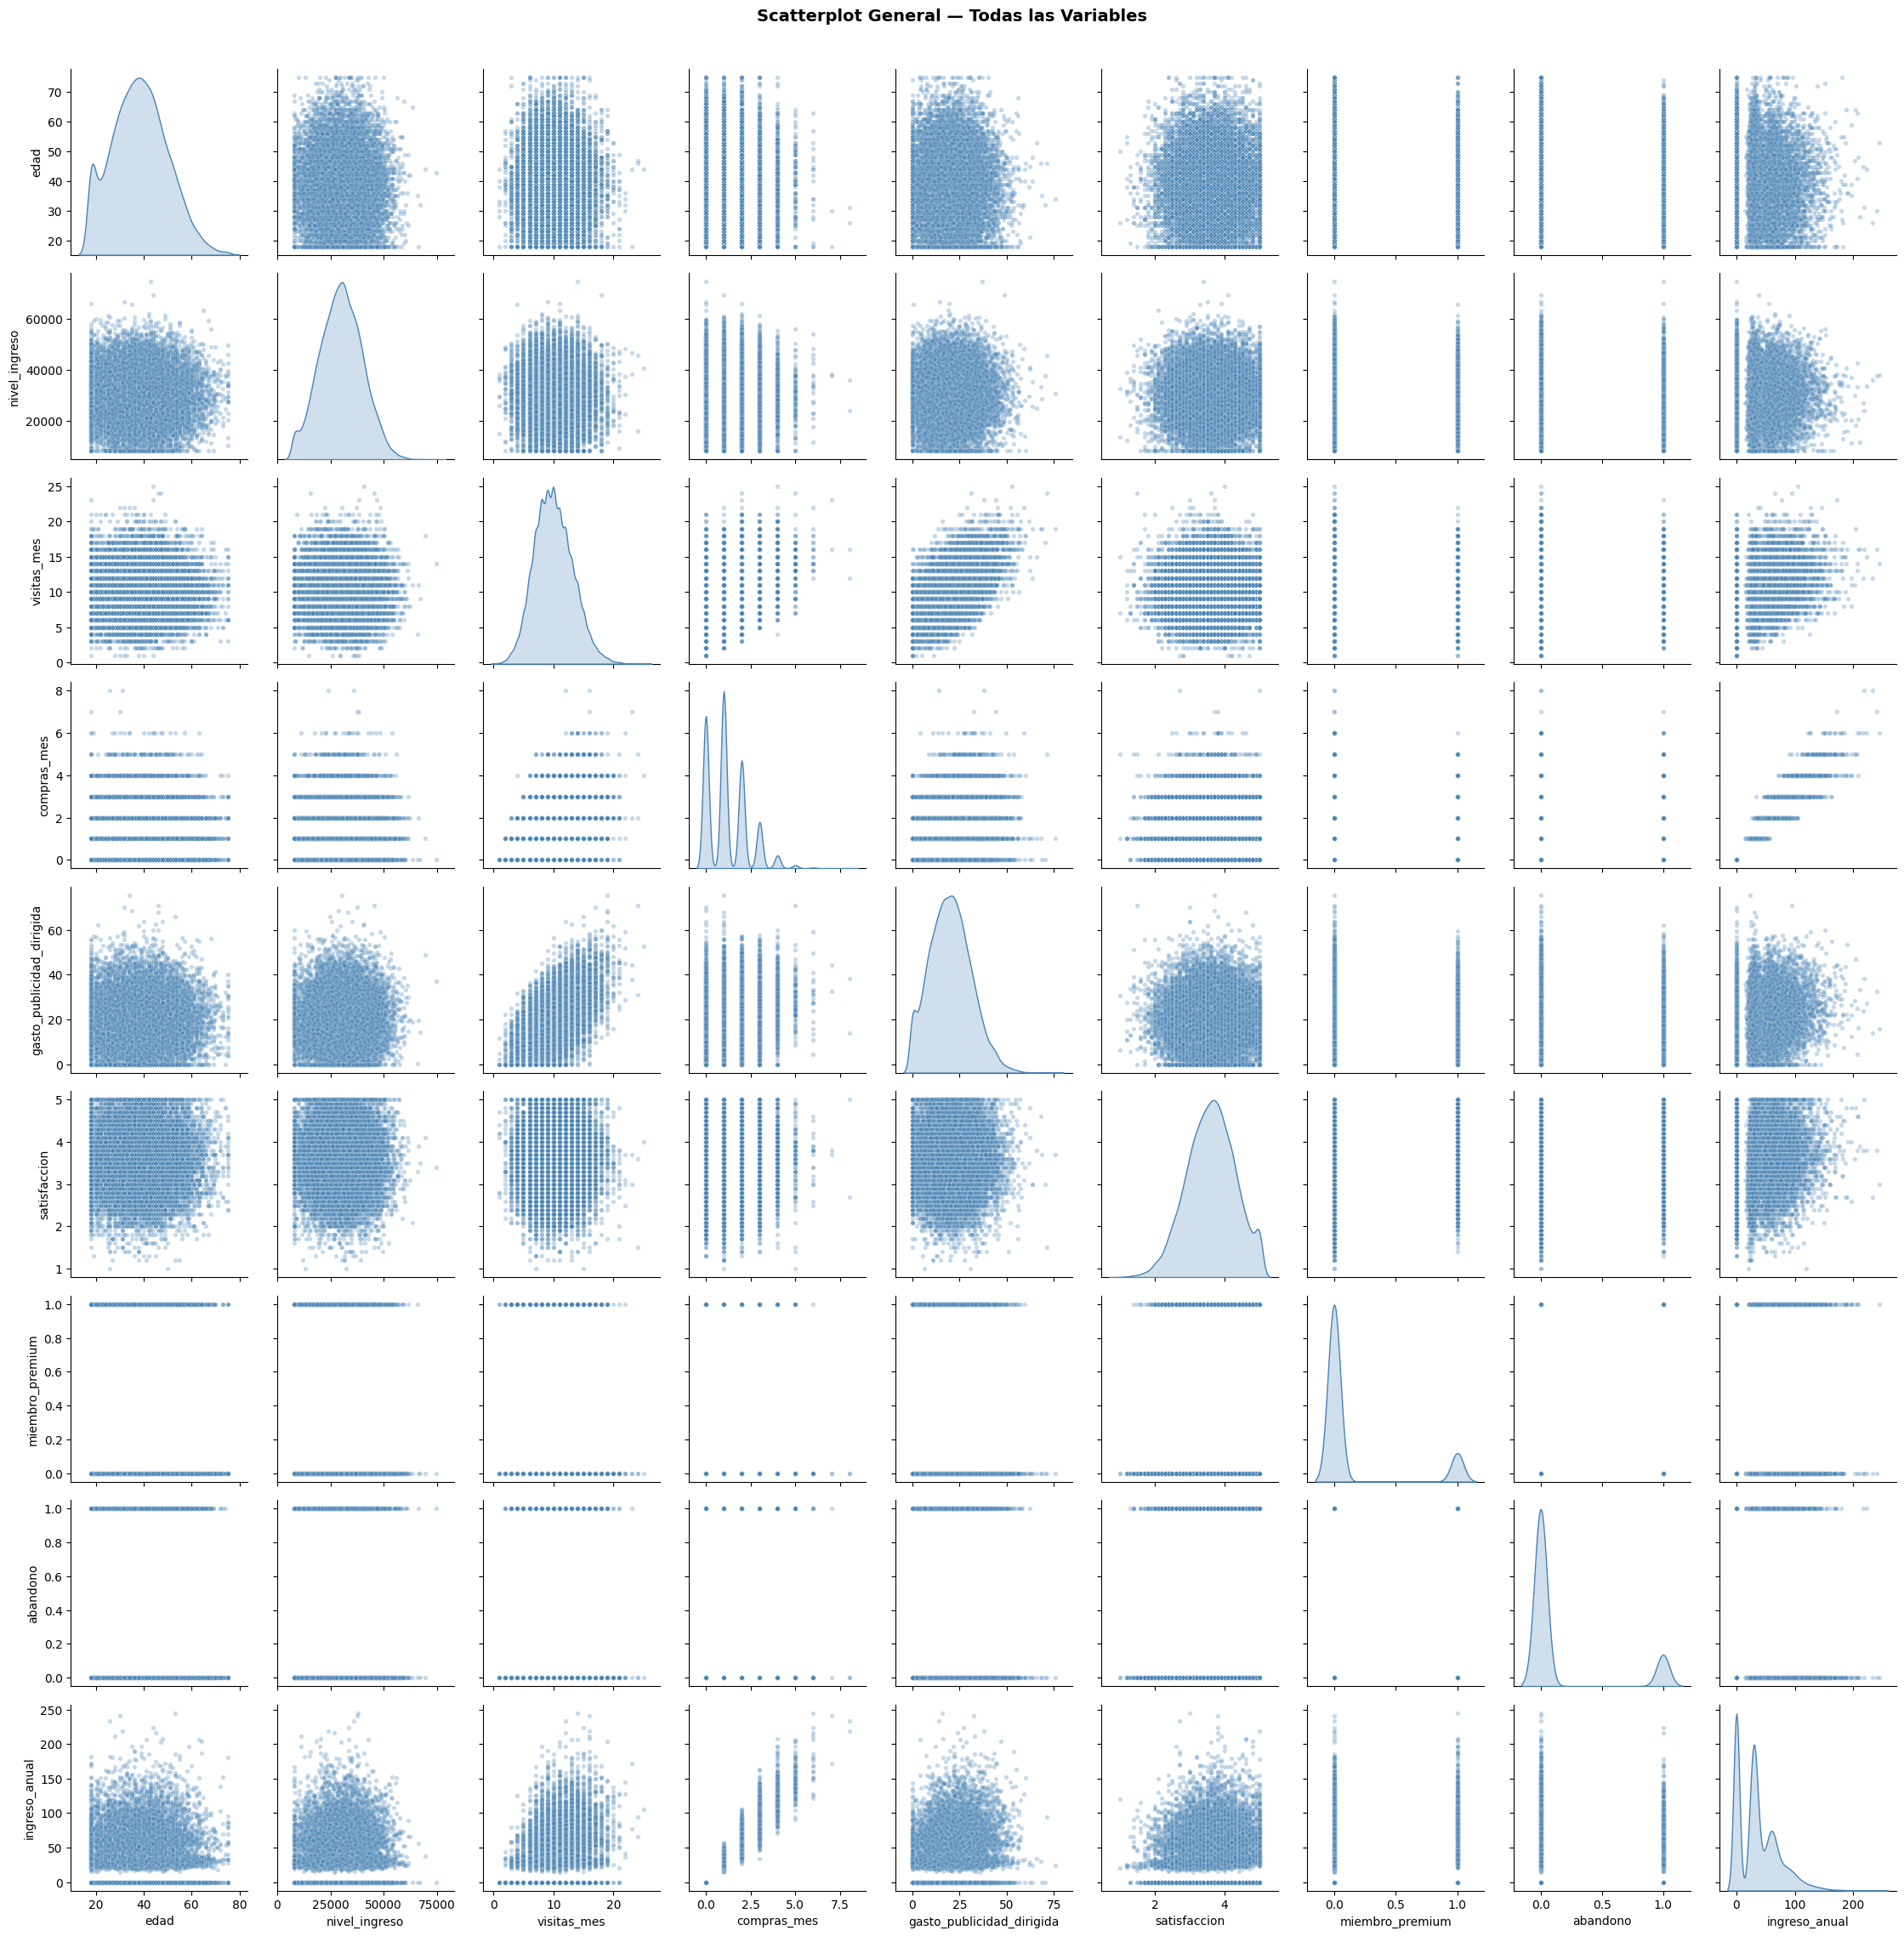

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ["edad", "nivel_ingreso", "visitas_mes", "compras_mes",
             "gasto_publicidad_dirigida", "satisfaccion",
             "miembro_premium", "abandono", "ingreso_anual"]

g = sns.pairplot(
    df[variables],
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 15, "color": "steelblue"},
    diag_kws={"color": "steelblue", "fill": True}
)

g.fig.suptitle("Scatterplot General — Todas las Variables",
               fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

### Scatterplot para pares clave

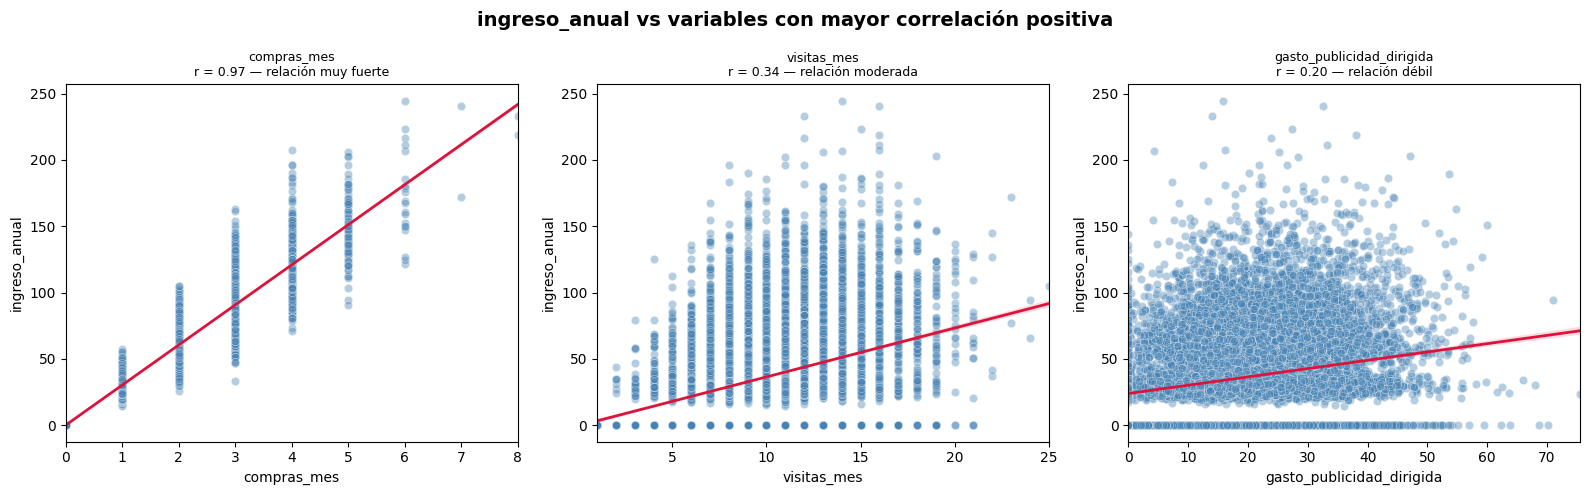

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    ("compras_mes",                "r = 0.97 — relación muy fuerte"),
    ("visitas_mes",                "r = 0.34 — relación moderada"),
    ("gasto_publicidad_dirigida",  "r = 0.20 — relación débil"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ingreso_anual vs variables con mayor correlación positiva",
             fontsize=14, fontweight="bold")

for ax, (var, label) in zip(axes, variables):
    sns.scatterplot(data=df, x=var, y="ingreso_anual",
                    alpha=0.4, ax=ax, color="steelblue")
    sns.regplot(data=df, x=var, y="ingreso_anual", ax=ax,
                scatter=False, line_kws={"color": "crimson", "linewidth": 2})
    ax.set_title(f"{var}\n{label}", fontsize=9)
    ax.set_xlabel(var)
    ax.set_ylabel("ingreso_anual")

plt.tight_layout()
plt.show()

## Observaciones iniciales (Scatterplot)

### `compras_mes` vs `ingreso_anual` (r = 0.97)
- **Dirección:** Positiva clara — a mayor número de compras mensuales,
  mayor ingreso anual.
- **Dispersión:** Baja — los puntos se agrupan de forma muy cercana
  a la línea de regresión.
- **Outliers:** Se sugiere la presencia de algunos valores atípicos
  en los niveles 5, 6 y 7 de compras, donde el ingreso anual
  presenta mayor variabilidad.
- **Colinealidad:** El patrón numérico y visual es un indicativo fuerte
  de colinealidad. Con r = 0.97 se sugiere que ambas variables estarían
  midiendo esencialmente lo mismo, por lo que se recomienda considerar
  la exclusión de `compras_mes` del análisis.

---

### `visitas_mes` vs `ingreso_anual` (r = 0.34)
- **Dirección:** Positiva débil — existe una ligera tendencia ascendente,
  aunque poco pronunciada.
- **Dispersión:** Alta — los puntos se distribuyen ampliamente alrededor
  de la línea de regresión, sugiriendo que `visitas_mes` explicaría
  solo una pequeña proporción de la variabilidad del ingreso anual.
- **Outliers:** Se sugiere la presencia de valores atípicos en niveles
  altos de visitas (> 20), donde el ingreso presenta saltos considerables.
- **Colinealidad:** No se sugiere riesgo. La correlación moderada indica
  que ambas variables aportarían información independiente al modelo.

---

### `gasto_publicidad_dirigida` vs `ingreso_anual` (r = 0.20)
- **Dirección:** Positiva muy débil — la línea de regresión presenta
  una pendiente casi plana, indicando una asociación marginal entre
  ambas variables.
- **Dispersión:** Muy alta — la nube de puntos es densa y uniforme,
  sin una estructura clara que sugiera una tendencia definida.
- **Outliers:** Se observan valores atípicos dispersos en niveles
  medios y altos de gasto publicitario, sin un patrón consistente.
- **Colinealidad:** No se sugiere riesgo. La correlación débil (r = 0.20)
  indica que esta variable aportaría información mayormente independiente
  respecto al ingreso anual.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
# Correlación de Pearson con ingreso_anual
import pandas as pd

variables = ["compras_mes", "visitas_mes", "gasto_publicidad_dirigida",
             "edad", "nivel_ingreso", "satisfaccion",
             "miembro_premium", "abandono"]

pearson_corr = df[variables + ["ingreso_anual"]].corr(method="pearson")["ingreso_anual"].drop("ingreso_anual")

pearson_df = pd.DataFrame({
    "Pearson": pearson_corr.round(4)
}).sort_values("Pearson", ascending=False)

print(pearson_df.to_string())

                           Pearson
compras_mes                 0.9671
visitas_mes                 0.3371
gasto_publicidad_dirigida   0.1975
miembro_premium             0.0931
satisfaccion                0.0562
edad                        0.0175
nivel_ingreso               0.0174
abandono                   -0.0028


In [ ]:
# Calcular correlación entre variables relevantes
# Correlación de Spearman con ingreso_anual
spearman_corr = df[variables + ["ingreso_anual"]].corr(method="spearman")["ingreso_anual"].drop("ingreso_anual")

spearman_df = pd.DataFrame({
    "Spearman": spearman_corr.round(4)
}).sort_values("Spearman", ascending=False)

print(spearman_df.to_string())

                           Spearman
compras_mes                  0.9675
visitas_mes                  0.3210
gasto_publicidad_dirigida    0.1850
miembro_premium              0.0919
satisfaccion                 0.0608
nivel_ingreso                0.0250
edad                         0.0161
abandono                     0.0007


## Observaciones de Correlación — Pearson vs Spearman

---

### `compras_mes` vs `ingreso_anual`
- **Pearson: 0.9671 | Spearman: 0.9675**
- Ambos métodos arrojan valores prácticamente idénticos, lo que sugiere
  que la relación sería lineal, robusta y consistente independientemente
  del método utilizado.
- Es el indicativo numérico más fuerte de posible **colinealidad** en
  el dataset. Con coeficientes de ~0.97 en ambos métodos, se reitera
  la recomendación de considerar la **exclusión de `compras_mes`**
  antes de proceder con el modelado.

---

### `visitas_mes` vs `ingreso_anual`
- **Pearson: 0.3371 | Spearman: 0.3210**
- Ambos métodos sugieren una relación positiva débil a moderada.
  La ligera diferencia entre métodos (0.016) indicaría que la relación
  sería predominantemente lineal, con una dispersión considerable
  que limitaría su poder explicativo sobre el ingreso anual.
- No se sugiere riesgo de colinealidad.

---

### `gasto_publicidad_dirigida` vs `ingreso_anual`
- **Pearson: 0.1975 | Spearman: 0.1850**
- Ambos métodos coinciden en una relación positiva débil.
  La diferencia entre métodos (0.012) es marginal, sugiriendo
  una relación aproximadamente lineal pero de baja magnitud.
- No se sugiere riesgo de colinealidad.

---

### `miembro_premium` vs `ingreso_anual`
- **Pearson: 0.0931 | Spearman: 0.0919**
- Correlación positiva muy débil y consistente entre métodos.
  Al ser variable binaria, los coeficientes deben interpretarse
  con cautela. Se sugeriría complementar con una prueba
  **Point-Biserial** para mayor precisión.

---

### `satisfaccion` vs `ingreso_anual`
- **Pearson: 0.0562 | Spearman: 0.0608**
- Correlación prácticamente nula en ambos métodos, sugiriendo
  que el nivel de satisfacción del cliente no tendría una asociación
  lineal ni monótona relevante con el ingreso anual.

---

### `edad` y `nivel_ingreso` vs `ingreso_anual`
- **Pearson: ~0.017 | Spearman: ~0.016 - 0.025**
- Correlaciones cercanas a cero en ambos métodos. Los resultados
  sugieren que ni la edad ni el nivel de ingreso categórico
  tendrían una relación estadísticamente relevante con
  el ingreso anual dentro de este dataset.

---

### `abandono` vs `ingreso_anual`
- **Pearson: -0.0028 | Spearman: 0.0007**
- Correlación nula. Adicionalmente, el cambio de signo entre métodos
  (-0.0028 vs 0.0007) sugeriría que no existiría ninguna relación
  sistemática entre el abandono del cliente y su ingreso anual.

---

### 📋 Resumen comparativo

| Variable | Pearson | Spearman | Diferencia | Riesgo colinealidad |
|---|---|---|---|---|
| `compras_mes` | 0.9671 | 0.9675 | 0.0004 | ⚠️ Alto |
| `visitas_mes` | 0.3371 | 0.3210 | 0.0161 | ✅ Bajo |
| `gasto_publicidad_dirigida` | 0.1975 | 0.1850 | 0.0125 | ✅ Bajo |
| `miembro_premium` | 0.0931 | 0.0919 | 0.0012 | ✅ Bajo |
| `satisfaccion` | 0.0562 | 0.0608 | 0.0046 | ✅ Bajo |
| `nivel_ingreso` | 0.0174 | 0.0250 | 0.0076 | ✅ Bajo |
| `edad` | 0.0175 | 0.0161 | 0.0014 | ✅ Bajo |
| `abandono` | -0.0028 | 0.0007 | 0.0035 | ✅ Bajo |

### Punto-biserial

In [ ]:
# Point-Biserial: variables binarias vs ingreso_anual
from scipy.stats import pointbiserialr

binarias = ["miembro_premium", "abandono"]

print("Point-Biserial — Variables Binarias vs ingreso_anual")
print("=" * 55)
for var in binarias:
    corr, pvalue = pointbiserialr(df[var], df["ingreso_anual"])
    print(f"{var:<25} | r = {corr:.4f} | p-value = {pvalue:.4f}")

Point-Biserial — Variables Binarias vs ingreso_anual
miembro_premium           | r = 0.0931 | p-value = 0.0000
abandono                  | r = -0.0028 | p-value = 0.7295


## Observaciones Point-Biserial — Variables Binarias vs `ingreso_anual`

---

### `miembro_premium` vs `ingreso_anual`
- **r = 0.0931 | p-value = 0.0000**
- Relación positiva de magnitud **muy débil**, aunque estadísticamente
  significativa (p < 0.05). Esto sugeriría que ser miembro premium
  estaría ligeramente asociado con un mayor ingreso anual, sin embargo,
  la baja magnitud del coeficiente indica que esta variable explicaría
  una proporción muy pequeña de la variabilidad del ingreso anual.

---

### `abandono` vs `ingreso_anual`
- **r = -0.0028 | p-value = 0.7295**
- Relación negativa de magnitud **nula** y estadísticamente
  **no significativa** (p > 0.05). Los resultados sugieren que
  el abandono del cliente no tendría ninguna asociación relevante
  con el ingreso anual, por lo que esta variable no aportaría
  valor explicativo respecto a la variable objetivo.

### V de Cramér

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

categoricas = ["nivel_ingreso", "satisfaccion", "miembro_premium", "abandono"]

df["ingreso_anual_bin"] = pd.qcut(df["ingreso_anual"], q=4,
                                   labels=False,
                                   duplicates="drop")



In [ ]:
# Aplicar V de Cramér en variables relevantes

print("V de Cramér — Variables Categóricas vs ingreso_anual_bin")
print("=" * 55)

for var in categoricas:
    v = cramers_v(df[var], df["ingreso_anual_bin"])
    print(f"{var:<25} | V = {v:.4f}")

V de Cramér — Variables Categóricas vs ingreso_anual_bin
nivel_ingreso             | V = 0.9922
satisfaccion              | V = 0.0818
miembro_premium           | V = 0.1221
abandono                  | V = 0.0079


## Observaciones V de Cramér — Variables Categóricas vs `ingreso_anual_bin`

---

### `nivel_ingreso` vs `ingreso_anual_bin`
- **V = 0.9922**
- Asociación **muy fuerte**, prácticamente perfecta. Este resultado
  es un indicativo fuerte de que `nivel_ingreso` e `ingreso_anual`
  estarían midiendo esencialmente la misma dimensión, sugiriendo
  una posible **redundancia entre variables**.
- Se recomendaría considerar la **exclusión de `nivel_ingreso`**
  del análisis, de forma similar a lo sugerido con `compras_mes`,
  para evitar introducir información duplicada en el modelo.

---

### `satisfaccion` vs `ingreso_anual_bin`
- **V = 0.0818**
- Asociación **muy débil**. Los resultados sugieren que el nivel de
  satisfacción no tendría una asociación relevante con el ingreso anual,
  siendo consistente con los coeficientes de Pearson (0.0562)
  y Spearman (0.0608) obtenidos previamente.

---

### `miembro_premium` vs `ingreso_anual_bin`
- **V = 0.1221**
- Asociación **débil**. Sugiere que ser miembro premium tendría
  una asociación marginal con el ingreso anual, complementando
  lo observado en el análisis Point-Biserial (r = 0.0931).
  Ambos métodos apuntan en la misma dirección, aunque con
  una magnitud insuficiente para considerarla relevante.

---

### `abandono` vs `ingreso_anual_bin`
- **V = 0.0079**
- Asociación **prácticamente nula**. Consistente con todos los
  métodos aplicados previamente — Pearson (-0.0028), Spearman (0.0007)
  y Point-Biserial (-0.0028) — los resultados sugieren de forma
  reiterada que el abandono del cliente no tendría ninguna asociación
  relevante con el ingreso anual.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — `compras_mes` y `nivel_ingreso` presentan redundancia con `ingreso_anual`
**Evidencia visual:** El scatterplot de `compras_mes` vs `ingreso_anual` muestra
una estructura de bandas casi perfectamente alineadas con la línea de regresión.

**Evidencia numérica:** Pearson = 0.9671, Spearman = 0.9675 para `compras_mes`;
V de Cramér = 0.9922 para `nivel_ingreso`. Ambos indicadores sugieren una
asociación prácticamente perfecta con `ingreso_anual`.

**Interpretación:** Los resultados sugieren que `compras_mes` y `nivel_ingreso`
estarían capturando esencialmente la misma información que `ingreso_anual`,
lo que podría representar redundancia en el dataset.

**No podemos afirmar:** Que exista una relación causal entre estas variables,
ni que su exclusión mejore necesariamente el desempeño de un modelo predictivo
sin validación formal previa.

**Implicación de negocio:** Se recomendaría considerar la exclusión de
`compras_mes` y `nivel_ingreso` en futuros modelos para evitar multicolinealidad,
conservando `ingreso_anual` como variable representativa central del análisis.

---

### Hallazgo 2 — La publicidad dirigida podría estar asociada con un mayor número de visitas
**Evidencia visual:** El scatterplot de `visitas_mes` vs `gasto_publicidad_dirigida`
muestra una nube de puntos con tendencia positiva moderada y alta dispersión.

**Evidencia numérica:** Pearson = 0.58, Spearman = 0.58 entre `visitas_mes`
y `gasto_publicidad_dirigida`.

**Interpretación:** Los resultados sugieren que una mayor inversión en publicidad
dirigida podría estar asociada con un incremento en las visitas mensuales,
aunque la alta dispersión indicaría que existen otros factores que también
influirían en el tráfico.

**No podemos afirmar:** Que la publicidad dirigida sea la causa directa del
aumento de visitas, ni que incrementar el presupuesto publicitario garantice
proporcionalmente más visitas.

**Implicación de negocio:** Podría ser de interés para el área de marketing
analizar con mayor profundidad qué segmentos de clientes responden mejor
a la publicidad dirigida, para optimizar la inversión publicitaria.

---

### Hallazgo 3 — Las visitas mensuales tendrían una asociación débil con el ingreso anual
**Evidencia visual:** El scatterplot de `visitas_mes` vs `ingreso_anual` muestra
una tendencia positiva débil con alta dispersión alrededor de la línea de regresión.

**Evidencia numérica:** Pearson = 0.3371, Spearman = 0.3210.

**Interpretación:** Los resultados sugieren que un mayor número de visitas
mensuales podría estar ligeramente asociado con un mayor ingreso anual,
aunque la magnitud del coeficiente indicaría que esta relación sería
poco determinante por sí sola.

**No podemos afirmar:** Que aumentar las visitas incremente directamente
el ingreso anual, ni que esta variable sea un predictor confiable
del ingreso sin considerar otras variables del modelo.

**Implicación de negocio:** Las visitas por sí solas no serían un indicador
suficiente del valor del cliente. Se sugeriría complementar este análisis
con métricas de conversión para entender mejor el comportamiento
del usuario dentro del sitio.

---

### Hallazgo 4 — La membresía premium tendría una asociación marginal con el ingreso anual
**Evidencia visual:** No aplica — variable binaria no informativa en scatterplot.

**Evidencia numérica:** Point-Biserial r = 0.0931 (p = 0.0000),
V de Cramér = 0.1221.

**Interpretación:** Aunque estadísticamente significativa, la magnitud
del coeficiente sugiere que ser miembro premium tendría una asociación
muy débil con el ingreso anual. La significancia estadística podría
estar influenciada por el tamaño del dataset más que por una
asociación prácticamente relevante.

**No podemos afirmar:** Que la membresía premium sea un determinante
del ingreso anual, ni que los clientes premium generen significativamente
más ingresos que los no premium.

**Implicación de negocio:** Se recomendaría revisar la estrategia
del programa premium para evaluar si efectivamente está captando
a los clientes de mayor valor, o si su adopción es independiente
del nivel de ingreso del cliente.

---


### Hallazgo 5 — El abandono no mostraría asociación con el ingreso anual
**Evidencia visual:** No aplica — variable binaria no informativa en scatterplot.

**Evidencia numérica:** Pearson = -0.0028, Spearman = 0.0007,
Point-Biserial = -0.0028 (p = 0.7295), V de Cramér = 0.0079.

**Interpretación:** La totalidad de los métodos aplicados sugiere
de forma consistente que el abandono del cliente no tendría ninguna
asociación relevante con el ingreso anual. El p-value no significativo
(0.7295) refuerza esta interpretación.

**No podemos afirmar:** Que los clientes de mayor ingreso sean
más o menos propensos a abandonar la plataforma, ni que el ingreso
anual sea un factor predictor del churn.

**Implicación de negocio:** Los factores que explicarían el abandono
del cliente parecerían ser independientes del ingreso anual,
por lo que se recomendaría explorar otras dimensiones como
la experiencia del usuario, frecuencia de interacción o
satisfacción con el servicio para entender mejor el churn.

## Sección 6 - Limitaciones y próximos pasos

## Sección 6 — Limitaciones y Próximos Pasos

---

### Limitaciones

- **Correlación ≠ causalidad:** Ninguno de los hallazgos presentados
  permite establecer relaciones causales entre variables. Los coeficientes
  reportados describen asociaciones estadísticas que requerirían
  validación experimental para atribuir causalidad.

- **Variables redundantes no eliminadas:** El análisis se realizó con
  el dataset completo, incluyendo `compras_mes` y `nivel_ingreso`,
  que presentan indicios fuertes de redundancia con `ingreso_anual`.
  Su presencia podría estar distorsionando algunas asociaciones observadas.

- **Variables binarias limitadas:** `miembro_premium` y `abandono`
  al ser dicotómicas, restringen la capacidad expresiva de los métodos
  de correlación utilizados, pudiendo subestimar o sobreestimar
  algunas asociaciones reales.

- **Distribución asimétrica de `ingreso_anual`:** La alta concentración
  de valores en 0 dificultó la creación de cuartiles balanceados,
  lo que podría haber afectado los resultados del V de Cramér.

- **Análisis univariado:** El presente estudio evaluó cada variable
  de forma independiente respecto a `ingreso_anual`, sin considerar
  efectos de interacción entre variables que podrían revelar
  patrones adicionales.

---

### Próximos Pasos

**Paso 1 — Tratamiento de multicolinealidad**
- Calcular el Factor de Inflación de Varianza (VIF) para cuantificar
  formalmente la multicolinealidad antes de excluir variables.
- Evaluar si la exclusión de `compras_mes` y `nivel_ingreso` mejora
  la estabilidad de los modelos predictivos.

**Paso 2 — Segmentación de clientes**
- Explorar segmentación por clusters (K-Means o DBSCAN) para identificar
  grupos de clientes con patrones de ingreso diferenciados.
- Analizar si las correlaciones observadas se mantienen o varían
  dentro de cada segmento, lo que podría revelar relaciones
  ocultas a nivel agregado.

**Paso 3 — Modelado predictivo**
- Desarrollar un modelo de regresión con las variables no redundantes
  para estimar `ingreso_anual` y evaluar el poder predictivo
  del conjunto de variables disponibles.
- Incorporar pruebas de significancia estadística para validar
  formalmente los hallazgos sugeridos en este análisis exploratorio.